In [1]:
import pandas as pd
import numpy as np
import seaborn as sns                       
import matplotlib.pyplot as plt   

In [2]:
df = pd.read_csv("teen_phone_addiction_dataset.csv")
df

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,NaN,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Jesus Yates,16,Female,New Jennifer,12th,3.9,6.4,53,4,...,0.3,80,15,2.7,1.8,1.0,Other,8,9.4,9.8
2996,2997,Bethany Murray,13,Female,Richardport,8th,3.6,7.3,93,5,...,0.9,45,8,3.1,0.0,0.3,Gaming,9,5.2,5.5
2997,2998,Norman Hughes,14,Other,Rebeccaton,7th,3.2,6.5,98,1,...,0.2,51,13,2.4,0.2,2.4,Social Media,9,5.9,6.2
2998,2999,Barbara Hinton,17,Female,Ramirezmouth,9th,6.7,7.5,67,3,...,1.6,125,17,1.7,2.6,1.5,Browsing,4,6.1,10.0


### Question 1

Check Below
- DataFrame Shape
- Data Types
- Duplicate records (remove if found)
- Missing/Null Values (replace with median value)

In [5]:
#DataFrame Shape
df.shape

(3000, 25)

##### the dataset has 25 columns and 3000 rows

In [7]:
#Data Types
df.dtypes

ID                          int64
Name                       object
Age                         int64
Gender                     object
Location                   object
School_Grade               object
Daily_Usage_Hours         float64
Sleep_Hours               float64
Academic_Performance        int64
Social_Interactions         int64
Exercise_Hours            float64
Anxiety_Level               int64
Depression_Level            int64
Self_Esteem                 int64
Parental_Control            int64
Screen_Time_Before_Bed    float64
Phone_Checks_Per_Day        int64
Apps_Used_Daily             int64
Time_on_Social_Media      float64
Time_on_Gaming            float64
Time_on_Education         float64
Phone_Usage_Purpose        object
Family_Communication        int64
Weekend_Usage_Hours       float64
Addiction_Level           float64
dtype: object

In [13]:
df.duplicated().sum()

0

##### no duplicates found

In [14]:
df.isnull().sum()

ID                         0
Name                       0
Age                        0
Gender                     0
Location                   0
School_Grade               0
Daily_Usage_Hours          5
Sleep_Hours                0
Academic_Performance       0
Social_Interactions        0
Exercise_Hours             8
Anxiety_Level              0
Depression_Level           0
Self_Esteem                0
Parental_Control           0
Screen_Time_Before_Bed    15
Phone_Checks_Per_Day       0
Apps_Used_Daily            0
Time_on_Social_Media       0
Time_on_Gaming             0
Time_on_Education          0
Phone_Usage_Purpose        0
Family_Communication       0
Weekend_Usage_Hours        0
Addiction_Level            0
dtype: int64

##### Daily_Usage_Hours has 5 null values and Screen_Time_Before_Bed has 15 

In [16]:
#replacing null values with median values
df = df.fillna(df.median(numeric_only=True))

In [17]:
df.isnull().sum()

ID                        0
Name                      0
Age                       0
Gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
Sleep_Hours               0
Academic_Performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64

##### null values replaced with median successfully

### Question 2:

How does time spent on social media compare to time spent on education among teens?

- Plot side-by-side histograms of Time on Social Media and Time on Education
- Find and compare the median time for both.
- Write simple comments to explain what the data shows

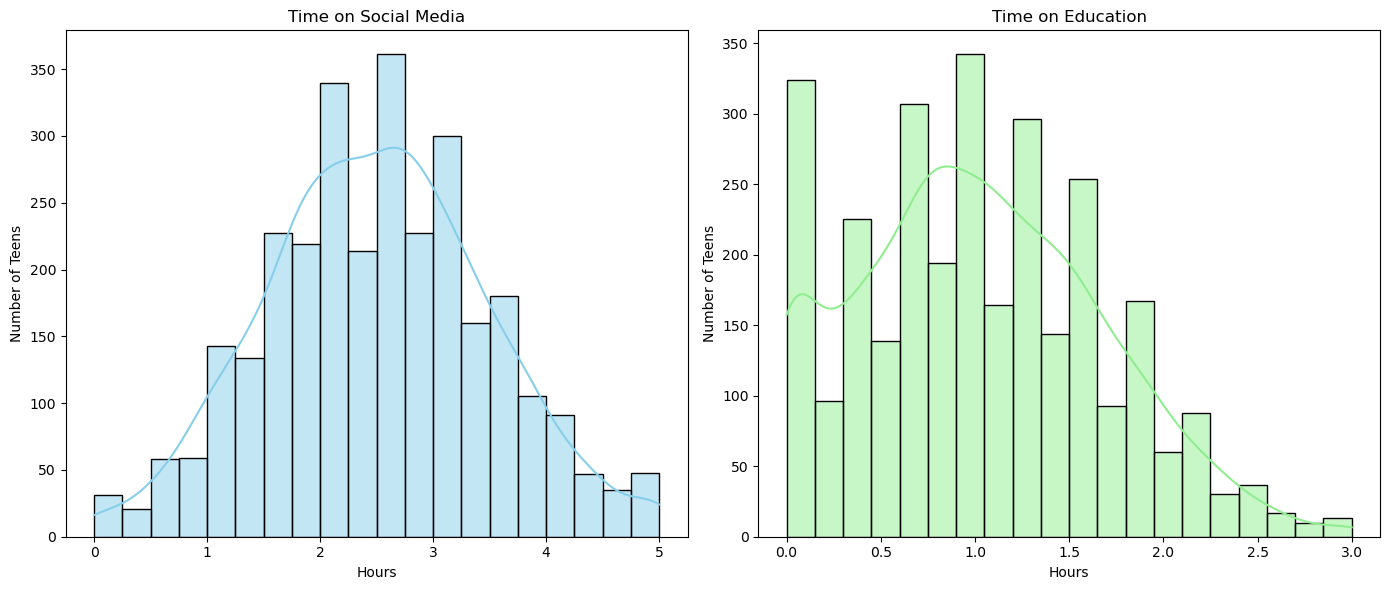

In [18]:
plt.figure(figsize=(14, 6))

# Histogram for Time on Social Media
plt.subplot(1, 2, 1)
sns.histplot(df['Time_on_Social_Media'], bins=20, color='skyblue', kde=True)
plt.title("Time on Social Media")
plt.xlabel("Hours")
plt.ylabel("Number of Teens")

# Histogram for Time on Education
plt.subplot(1, 2, 2)
sns.histplot(df['Time_on_Education'], bins=20, color='lightgreen', kde=True)
plt.title("Time on Education")
plt.xlabel("Hours")
plt.ylabel("Number of Teens")

# Adjust layout and display the plots
plt.tight_layout()
plt.show()


##### it is observed that social media usage appears to be more spread out, with a noticeable number of teens spending several hours on it, while education time might be more concentrated in fewer hours.

### Question 3

- How can we detect and identify outliers in Daily Usage Hours, Exercise Hours, and Screen Time Before Bed among teens using the IQR method?
- Display the records corresponding to these outliers using boxplot.



In [19]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] < lower) | (data[column] > upper)]


In [20]:
outliers_daily = detect_outliers_iqr(df, 'Daily_Usage_Hours')
outliers_daily


,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
227,228,Michael Hopkins,18,Female,North Austin,9th,10.6,9.1,93,8,...,1.4,36,7,3.7,1.2,2.5,Other,8,6.3,10.0
582,583,Julia Rogers,16,Female,Desireeland,8th,10.5,8.0,97,10,...,1.0,128,16,1.9,0.0,0.9,Social Media,10,3.7,10.0
710,711,Pamela Johnson,15,Male,Derrickville,8th,11.0,7.7,59,2,...,2.1,81,10,1.6,1.6,1.4,Browsing,8,6.2,10.0
881,882,Bridget Santos,18,Other,South Bobbyland,10th,10.6,6.7,79,6,...,0.5,97,20,1.0,1.8,2.2,Education,1,7.4,10.0
1210,1211,Jack Foster,14,Other,Moorefort,7th,10.3,7.3,51,4,...,0.9,91,14,3.9,2.3,0.0,Browsing,2,11.0,10.0
1549,1550,Thomas Mckinney,13,Other,North Patrick,10th,10.3,7.1,98,1,...,0.2,70,16,1.6,2.9,1.1,Gaming,3,7.4,10.0
1665,1666,Brian Pierce,15,Other,Fordtown,9th,10.9,5.2,54,1,...,1.2,68,16,3.2,0.9,1.9,Other,5,6.1,10.0
1731,1732,Patrick Adams,14,Female,Walkerview,8th,10.6,5.1,94,6,...,0.3,77,10,1.7,0.0,0.4,Browsing,7,3.5,10.0
2400,2401,Lisa Gonzalez,13,Male,Deborahmouth,11th,11.2,8.1,55,1,...,0.9,34,17,3.6,2.4,0.9,Browsing,5,8.2,10.0
2622,2623,Deanna Heath,17,Female,West Johntown,10th,10.3,7.0,57,2,...,1.0,136,20,3.9,1.7,0.2,Browsing,10,8.7,10.0


In [21]:
outliers_exercise = detect_outliers_iqr(df, 'Exercise_Hours')
outliers_exercise


,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
56,57,Mrs. Lauren Ayala,17,Other,Port Dustin,10th,3.3,6.1,78,2,...,1.2,141,17,1.9,1.0,0.2,Education,8,5.1,9.4
126,127,Sonya Armstrong,13,Other,North Brian,7th,4.4,5.0,68,7,...,1.8,70,18,2.4,1.1,0.7,Browsing,2,5.1,10.0
608,609,Alfred Crawford,17,Other,West Eric,11th,5.2,7.8,75,8,...,1.4,134,15,1.5,1.8,0.2,Other,6,5.7,10.0
632,633,Mary Warner,14,Other,Huntland,12th,6.9,7.9,52,4,...,0.9,92,10,3.3,1.8,0.9,Social Media,4,7.9,10.0
784,785,Craig Morales,16,Female,Patriciatown,9th,5.8,6.4,53,10,...,0.6,100,5,2.5,0.2,0.9,Browsing,6,6.9,8.3
963,964,Mr. Jeffrey Park,13,Female,East Felicia,9th,3.7,6.1,82,0,...,1.0,119,14,2.7,0.5,1.0,Gaming,3,5.6,9.0
1309,1310,Amy Peterson,18,Male,Sheilaborough,12th,4.5,3.0,67,2,...,0.5,129,8,2.5,1.5,0.4,Other,2,7.2,10.0
1487,1488,Steven Hall,19,Male,South Robertport,10th,3.9,8.0,76,4,...,0.9,63,9,2.4,0.1,1.5,Other,6,8.0,5.5
1546,1547,Kimberly Sanders,17,Other,North Pedro,7th,3.8,4.7,84,1,...,0.7,56,11,2.5,1.0,0.4,Other,4,7.2,8.3
1557,1558,Samantha Moore,13,Male,Coreyhaven,8th,0.3,4.5,54,3,...,1.1,47,18,2.5,2.4,1.3,Browsing,9,3.3,7.5


In [22]:
outliers_screen = detect_outliers_iqr(df, 'Screen_Time_Before_Bed')
outliers_screen

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
1775,1776,Katherine Williams,18,Male,New Joseph,7th,4.9,7.7,85,8,...,2.5,55,10,2.9,0.9,1.8,Browsing,1,6.1,8.0
1953,1954,Deborah Miller,16,Female,North David,8th,3.4,8.6,63,1,...,2.5,110,6,4.9,1.1,2.2,Social Media,8,3.2,8.5


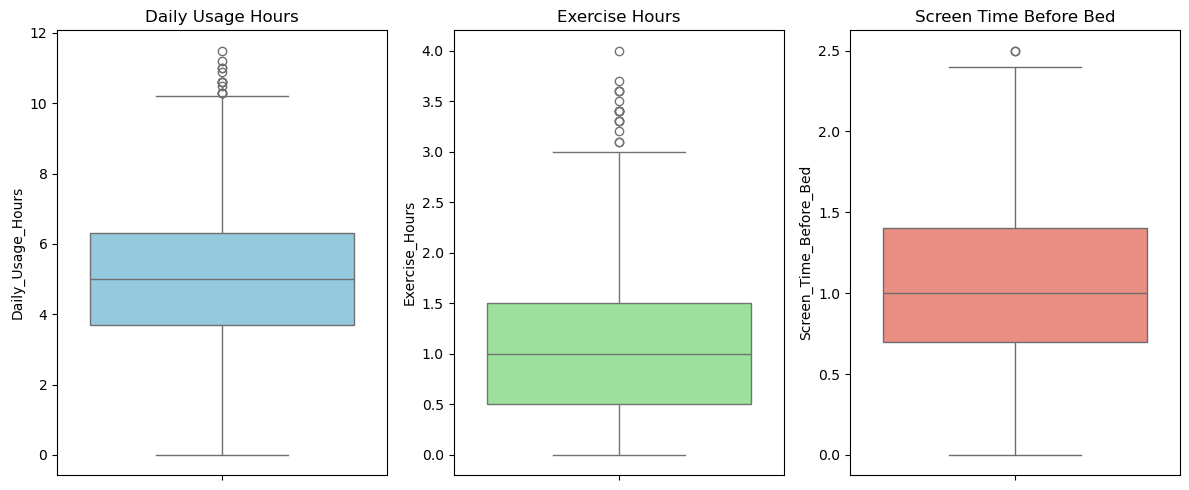

In [23]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['Daily_Usage_Hours'], color='skyblue')
plt.title("Daily Usage Hours")

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Exercise_Hours'], color='lightgreen')
plt.title("Exercise Hours")

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Screen_Time_Before_Bed'], color='salmon')
plt.title("Screen Time Before Bed")

plt.tight_layout()
plt.show()


#### Daily Usage Hours – 
##### Most teens use their phones for 3–7 hours, with some outliers using more than 10 hours.

#### Exercise Hours – 
##### Most teens exercise for 0.5–2 hours, with a few outliers exercising over 3 hours.

#### Screen Time Before Bed – 
##### Most teens spend 0.5–1.5 hours on screens before bed, with some outliers reaching up to 2.5 hours.









### Question 4

Analyze the correlation heatmap showing relationships between teen behaviors, screen usage, and mental health indicators.

Focus your attention on the following numeric variables:

- Daily_Usage_Hours, Sleep_Hours, Academic_Performance, Addiction_Level, Time_on_Social_Media,

- Time_on_Gaming, Time_on_Education, Apps_Used_Daily, Anxiety_Level, Depression_Level,

- Self_Esteem, Social_Interactions, Exercise_Hours, Screen_Time_Before_Bed,

- Phone_Checks_Per_Day, Family_Communication, Weekend_Usage_Hours


Identify two strong positive and two strong negative correlation involving any of the above variables.

Explain briefly what these correlations might suggest about teen behavior, wellbeing, or digital habits.

Use specific values from the heatmap to support your observation.



In [24]:
# List of selected numeric variables
cols = [
    'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Addiction_Level',
    'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Apps_Used_Daily',
    'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Social_Interactions',
    'Exercise_Hours', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day',
    'Family_Communication', 'Weekend_Usage_Hours'
]

# Select the subset
df_selected = df[cols]


In [25]:
# Calculate correlation matrix
corr_matrix = df_selected.corr()
corr_matrix.round(2)  # Optional: round for readability


,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Addiction_Level,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Apps_Used_Daily,Anxiety_Level,Depression_Level,Self_Esteem,Social_Interactions,Exercise_Hours,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Family_Communication,Weekend_Usage_Hours
Daily_Usage_Hours,1.00,0.02,0.02,0.60,-0.01,-0.01,0.01,0.02,-0.01,0.01,0.01,-0.03,-0.01,0.00,0.01,0.01,0.02
Sleep_Hours,0.02,1.00,-0.00,-0.22,-0.02,0.01,-0.01,0.03,0.01,-0.01,0.02,-0.02,0.01,-0.01,0.01,-0.03,-0.00
Academic_Performance,0.02,-0.00,1.00,0.01,0.04,-0.03,0.02,-0.03,0.00,-0.03,-0.01,0.01,-0.00,-0.01,-0.02,-0.03,0.01
Addiction_Level,0.60,-0.22,0.01,1.00,0.31,0.27,-0.00,0.32,0.02,0.01,-0.02,-0.01,-0.02,0.01,0.25,-0.01,-0.01
Time_on_Social_Media,-0.01,-0.02,0.04,0.31,1.00,-0.02,0.01,0.03,-0.00,0.00,-0.01,0.00,-0.02,-0.00,0.01,-0.02,-0.01
Time_on_Gaming,-0.01,0.01,-0.03,0.27,-0.02,1.00,-0.00,0.01,0.01,-0.01,-0.01,-0.00,-0.01,0.01,0.01,0.02,0.03
Time_on_Education,0.01,-0.01,0.02,-0.00,0.01,-0.00,1.00,-0.00,0.02,-0.03,-0.01,-0.01,0.02,0.03,-0.03,0.01,-0.02
Apps_Used_Daily,0.02,0.03,-0.03,0.32,0.03,0.01,-0.00,1.00,0.01,0.02,-0.03,-0.03,-0.01,0.03,-0.01,-0.01,-0.03
Anxiety_Level,-0.01,0.01,0.00,0.02,-0.00,0.01,0.02,0.01,1.00,0.02,0.00,0.00,0.00,-0.00,0.02,0.01,0.01
Depression_Level,0.01,-0.01,-0.03,0.01,0.00,-0.01,-0.03,0.02,0.02,1.00,-0.03,0.02,-0.01,-0.03,-0.00,-0.01,-0.01


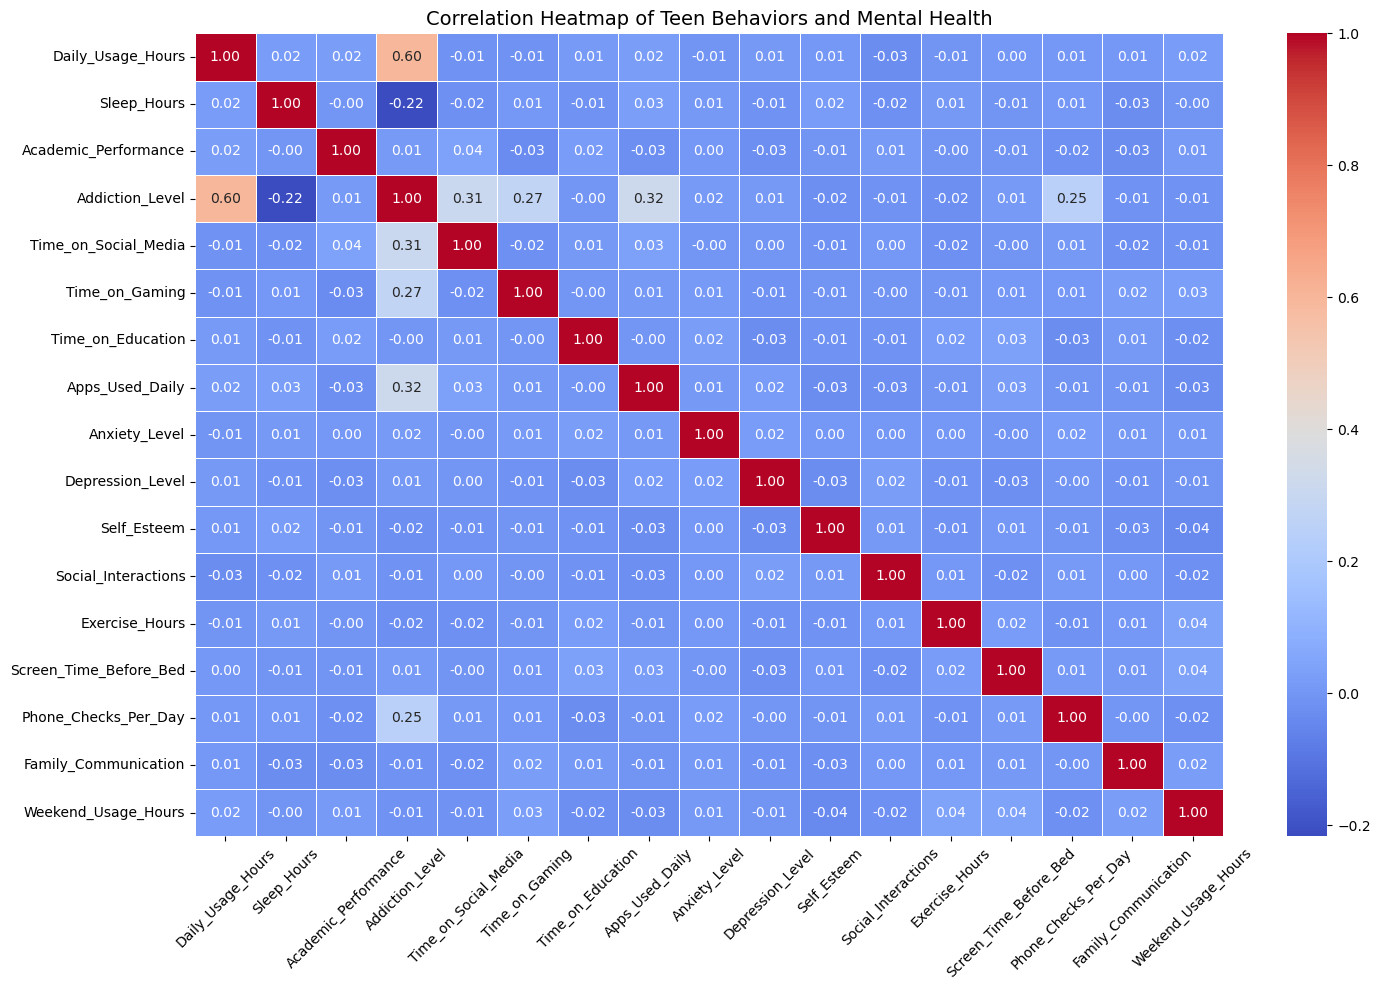

In [26]:

# Set plot size and style
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Teen Behaviors and Mental Health", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [28]:
# Get top 2 strong positive correlations
top_pos_corr = sorted_corr.head(2)

# Get top 2 strong negative correlations
top_neg_corr = sorted_corr.tail(2)

# Display results
print("Top 2 Positive Correlations:")
print(top_pos_corr)
print("\nTop 2 Negative Correlations:")
print(top_neg_corr)


Top 2 Positive Correlations:
                 Var1               Var2  Correlation
48    Addiction_Level  Daily_Usage_Hours       0.6005
2   Daily_Usage_Hours    Addiction_Level       0.6005

Top 2 Negative Correlations:
               Var1             Var2  Correlation
18      Sleep_Hours  Addiction_Level    -0.216681
49  Addiction_Level      Sleep_Hours    -0.216681


* Addiction ↑ with Daily Usage (0.60) – More phone time leads to higher addiction.
* Addiction ↑ with Apps Used (0.32) – Using more apps daily increases addiction.
* Addiction ↑ as Sleep ↓ (-0.22) – Less sleep is linked to more addiction.
* Self-Esteem ↓ with Weekend Use (-0.04) – Slight drop in self-esteem with weekend phone use.

### Question 5

How does the average addiction level vary across different age groups? Show with line graph

In [30]:
age_addiction = df.groupby('Age')['Addiction_Level'].mean().reset_index()


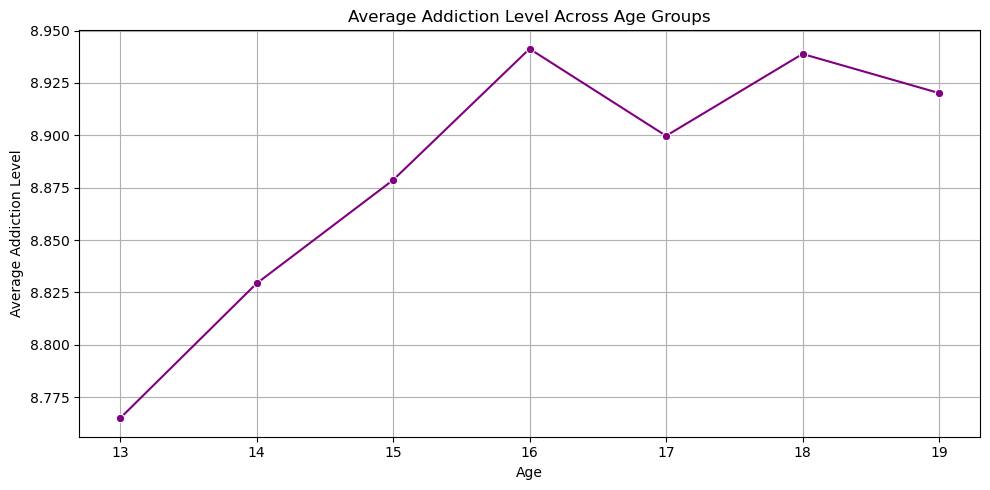

In [31]:
plt.figure(figsize=(10, 5))
sns.lineplot(x='Age', y='Addiction_Level', data=age_addiction, marker='o', color='purple')
plt.title("Average Addiction Level Across Age Groups")
plt.xlabel("Age")
plt.ylabel("Average Addiction Level")
plt.grid(True)
plt.tight_layout()
plt.show()


* Average addiction level slightly increases with age.
* Highest addiction level observed at age 16.
* Slight drop at age 17, then minor fluctuations.
* Addiction level remains high and consistent across all age groups.
* Mid-teen students (15–18) show the most noticeable variation.
